# Google Brain Ventilator Pressure Prediction - LightGBM ベースライン

**目的**: 人工呼吸器の吸気相における肺内圧（pressure）を予測する。

**ノートブックの流れ**（`google-brain-lightgbm-optuna` と同様の構成）  
分析設計 → データ前処理 → EDA → 特徴量エンジニアリング → データセット作成 → Optuna によるハイパーパラメータ探索（参考コード・コメントアウト）→ モデル学習（LightGBM / `LGBMRegressor`）→ 評価 → 特徴量重要度 → 提出用ファイル作成

---
## 1. 分析設計

コンペで何を予測し、どの指標で評価するかを明確にします。

| 項目 | 内容 | 選んだ根拠 |
|------|------|------------|
| **目的変数** | `pressure`（気道圧） | コンペの公式説明および Data タブの説明で「predict the pressure in the respiratory circuit」とされているため。 |
| **目的変数の種類** | **連続値（回帰）** | pressure は実数値（例: -1.895 ~ 64.0 程度）で、離散ラベルではなく連続的な物理量であるため。2値・カテゴリではない。 |
| **評価指標** | **MAE（Mean Absolute Error）** | コンペの「Evaluation」で MAE が指定されているため。予測圧と正解圧の絶対誤差の平均を最小化する。 |

**タスクの整理**  
- 時系列データ: 1 呼吸（breath）あたり 80 ステップ。各ステップで `time_step`, `u_in`, `u_out` が与えられ、そのステップの `pressure` を予測する。
- テストでは `pressure` が欠けているため、同じ形式の特徴量から pressure を予測して提出する。


---
## 2. ライブラリの読み込みとパス設定

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
# import optuna  # Optuna を使うときに有効化
import warnings

warnings.filterwarnings("ignore")

# Kaggle 環境専用パス（コンペの Data を追加したときのパス）
INPUT_DIR = "/kaggle/input/competitions/ventilator-pressure-prediction"
OUTPUT_DIR = "/kaggle/working/"
TRAIN_PATH = f"{INPUT_DIR}/train.csv"
TEST_PATH = f"{INPUT_DIR}/test.csv"
SAMPLE_SUBMISSION_PATH = f"{INPUT_DIR}/sample_submission.csv"
SUBMISSION_PATH = f"{OUTPUT_DIR}/submission.csv"

TARGET = "pressure"
ID_COL = "id"

pd.set_option("display.max_columns", 20)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
%matplotlib inline


---
## 3. データ前処理

データの読み込み、型・欠損の確認、breath 単位でソートして時系列の並びをそろえます。

In [31]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("【訓練データ】 行数:", len(train), ", 列数:", len(train.columns))
print("【テストデータ】 行数:", len(test), ", 列数:", len(test.columns))
print()
print("訓練データ 先頭5行:")
train.head()

【訓練データ】 行数: 6036000 , 列数: 8
【テストデータ】 行数: 4024000 , 列数: 7

訓練データ 先頭5行:


,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987


In [6]:
train.info()
print()
print("欠損値:")
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB

欠損値:
id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64


In [7]:
# breath_id と time_step でソート（時系列の順序を保つ）
train = train.sort_values(["breath_id", "time_step"]).reset_index(drop=True)
test = test.sort_values(["breath_id", "time_step"]).reset_index(drop=True)
print("breath_id, time_step でソート済み")

breath_id, time_step でソート済み


---
## 4. EDA（探索的データ分析）

`google-brain-lightgbm-optuna` と同様に、要約統計・カテゴリ（`R`, `C`）の件数・主要変数の分布・テスト先頭行を確認します。

In [8]:
train.describe()

,id,breath_id,R,C,time_step,u_in,u_out,pressure
count,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06
mean,3.018000e+06,6.283886e+04,2.703618e+01,2.608072e+01,1.307225e+00,7.321615e+00,6.204493e-01,1.122041e+01
std,1.742443e+06,3.633526e+04,1.959549e+01,1.715231e+01,7.659778e-01,1.343470e+01,4.852752e-01,8.109703e+00
min,1.000000e+00,1.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-1.895744e+00
25%,1.509001e+06,3.137700e+04,5.000000e+00,1.000000e+01,6.428995e-01,3.936623e-01,0.000000e+00,6.329607e+00
50%,3.018000e+06,6.276550e+04,2.000000e+01,2.000000e+01,1.308123e+00,4.386146e+00,1.000000e+00,7.032628e+00
75%,4.527000e+06,9.430100e+04,5.000000e+01,5.000000e+01,1.965502e+00,4.983895e+00,1.000000e+00,1.364103e+01
max,6.036000e+06,1.257490e+05,5.000000e+01,5.000000e+01,2.937238e+00,1.000000e+02,1.000000e+00,6.482099e+01


In [9]:
print("欠損値（訓練）:")
print(train.isnull().sum())
print()
print("breath_id のユニーク数:", train["breath_id"].nunique())
print("各 breath のステップ数（先頭数件）:")
print(train["breath_id"].value_counts().head())

欠損値（訓練）:
id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

breath_id のユニーク数: 75450
各 breath のステップ数（先頭数件）:
breath_id
125749    80
1         80
2         80
3         80
4         80
Name: count, dtype: int64


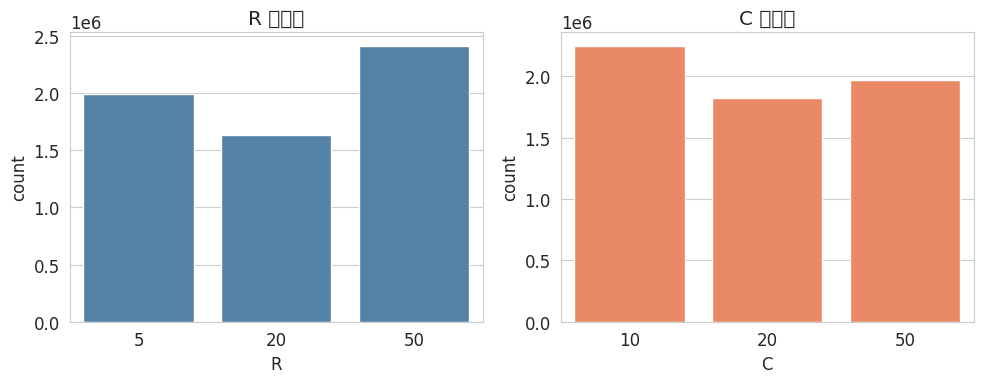

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=train, x="R", ax=axes[0], color="steelblue")
axes[0].set_title("R の件数")
sns.countplot(data=train, x="C", ax=axes[1], color="coral")
axes[1].set_title("C の件数")
plt.tight_layout()
plt.show()

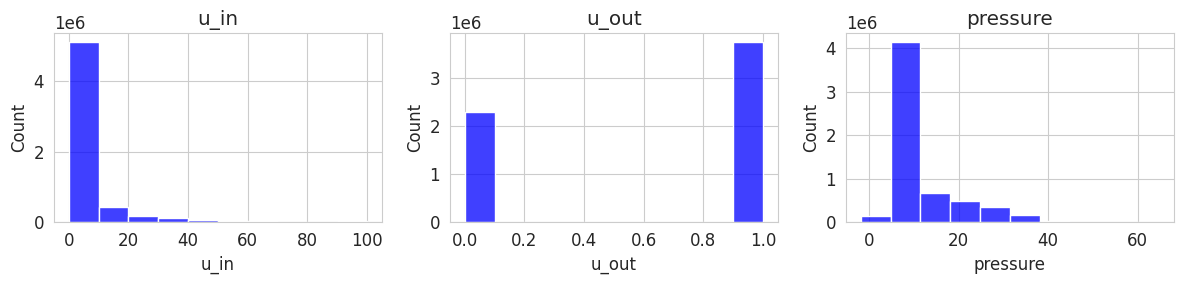

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.histplot(train["u_in"], bins=10, kde=False, color="blue", ax=axes[0])
axes[0].set_title("u_in")
sns.histplot(train["u_out"], bins=10, kde=False, color="blue", ax=axes[1])
axes[1].set_title("u_out")
sns.histplot(train[TARGET], bins=10, kde=False, color="blue", ax=axes[2])
axes[2].set_title(TARGET)
plt.tight_layout()
plt.show()

In [12]:
print("テストデータ 先頭5行:")
test.head()

テストデータ 先頭5行:


,id,breath_id,R,C,time_step,u_in,u_out
0,1,0,5,20,0.000000,0.000000,0
1,2,0,5,20,0.031904,7.515046,0
2,3,0,5,20,0.063827,14.651675,0
3,4,0,5,20,0.095751,21.230610,0
4,5,0,5,20,0.127644,26.320956,0


---
## 5. 特徴量エンジニアリング

`google-brain-lightgbm-optuna` と同様に、**同一 breath 内**の `u_in` について累積和（`u_in_cumsum`）と 2 ステップラグ（`u_in_lag`）を追加します。さらに施策4として、`u_in` の差分特徴量（`u_in_diff1`, `u_in_diff2`）と `R/C` の交互作用特徴量（`R_C_mul`, `R_C_div`）を追加します。  
※ 呼吸をまたがないよう、時系列由来の特徴は `breath_id` ごとに計算しています。

In [ ]:
train["u_in_cumsum"] = train.groupby("breath_id")["u_in"].cumsum()
test["u_in_cumsum"] = test.groupby("breath_id")["u_in"].cumsum()

train["u_in_lag"] = train.groupby("breath_id")["u_in"].shift(2).fillna(0)
test["u_in_lag"] = test.groupby("breath_id")["u_in"].shift(2).fillna(0)

# 施策4: u_in 差分特徴量
train["u_in_diff1"] = train.groupby("breath_id")["u_in"].diff(1).fillna(0)
train["u_in_diff2"] = train.groupby("breath_id")["u_in"].diff(2).fillna(0)
test["u_in_diff1"] = test.groupby("breath_id")["u_in"].diff(1).fillna(0)
test["u_in_diff2"] = test.groupby("breath_id")["u_in"].diff(2).fillna(0)

# 施策4: R/C 交互作用特徴量
train["R_C_mul"] = train["R"] * train["C"]
test["R_C_mul"] = test["R"] * test["C"]
train["R_C_div"] = train["R"] / train["C"]
test["R_C_div"] = test["R"] / test["C"]

print("特徴量追加後の列（訓練）:", list(train.columns))

特徴量追加後の列（訓練）: ['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out', 'pressure', 'u_in_cumsum', 'u_in_lag']


---
## 6. データセット作成（施策5: ワイドフォーマット）

**施策5**として、`u_out=0`（吸気相）を対象に **1行=1breath** のワイドフォーマットへ変換します。
説明変数は `u_in_step*`, `u_out_step*` と `R`, `C`、目的変数は `pressure_step*`（マルチターゲット）です。


In [14]:
train_insp = train[train["u_out"] == 0].copy()
test_insp = test[test["u_out"] == 0].copy()

def to_wide(df, value_cols, id_col="breath_id"):
    tmp = df.copy()
    tmp["step"] = tmp.groupby(id_col).cumcount()
    wide = tmp.pivot(index=id_col, columns="step", values=value_cols)
    wide.columns = [f"{col}_step{step}" for col, step in wide.columns]
    rc = tmp.groupby(id_col)[["R", "C"]].first()
    return wide.join(rc)

X_wide = to_wide(train_insp, value_cols=["u_in", "u_out"])
y_wide = to_wide(train_insp, value_cols=[TARGET])

# test 側のワイド特徴量（吸気相のみ）
X_test_wide = to_wide(test_insp, value_cols=["u_in", "u_out"])

# train/test で列を揃える（不足列は 0 補完）
X_test_wide = X_test_wide.reindex(columns=X_wide.columns, fill_value=0)

# 提出時に id へ戻すためのキー
test_insp_key = test_insp[["id", "breath_id"]].copy()
test_insp_key["step"] = test_insp.groupby("breath_id").cumcount()

groups = X_wide.index.to_numpy()
X = X_wide
y = y_wide

print("施策5: 吸気相をワイド化して学習")
print("X_wide shape:", X.shape)
print("y_wide shape:", y.shape)
print("X_test_wide shape:", X_test_wide.shape)
print("ターゲット列数:", y.shape[1])


施策1（方法B）: 訓練は u_out=0（吸気相）のみ。除外した呼気行数: 3745032
特徴量列: ['R', 'C', 'time_step', 'u_in', 'u_out', 'u_in_cumsum', 'u_in_lag']
X shape: (2290968, 7)
X_test shape: (4024000, 7)


---
## 7. ハイパーパラメータ探索（Optuna / GroupKFold）

施策2として Optuna による再チューニングを実行します。
ここでは `u_out=0` の学習データ（施策1方法B）を対象に、`GroupKFold`（`breath_id`単位）での平均MAE最小化で探索します。


In [15]:
# N_FOLDS = 5
# groups = train_insp["breath_id"]

# def objective(trial):
    # params = {
        # "objective": "regression",
        # "metric": "mae",
        # "boosting_type": "gbdt",
        # "n_estimators": 900,
        # "random_state": 42,
        # "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        # "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        # "max_depth": trial.suggest_int("max_depth", 4, 12),
        # "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        # "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        # "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        # "min_child_weight": trial.suggest_int("min_child_weight", 1, 256),
        # "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
        # "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        # "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        # "verbose": -1,
    # }

    # gkf = GroupKFold(n_splits=N_FOLDS)
    # fold_maes = []

    # for train_idx, valid_idx in gkf.split(X, y, groups=groups):
        # X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        # y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        # model = lgb.LGBMRegressor(**params)
        # model.fit(X_train, y_train)
        # preds = model.predict(X_valid)
        # fold_maes.append(mean_absolute_error(y_valid, preds))

    # return float(np.mean(fold_maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=20)
# print("Number of finished trials:", len(study.trials))
# print("Best CV MAE:", study.best_value)
# print("Best trial params:", study.best_trial.params)


---
## 8. GroupKFold 学習（ワイド + マルチターゲット）

`GroupKFold`（5-fold）で breath 単位に分割し、`MultiOutputRegressor(LightGBM)` で `pressure_step*` を同時学習します。


In [16]:
lgb_params = {
    "objective": "regression",
    "metric": "mae",
    "boosting_type": "gbdt",
    "n_estimators": 900,
    "random_state": 42,
    "learning_rate": 0.03829428196449332,
    "num_leaves": 162,
    "max_depth": 12,
    "colsample_bytree": 0.8775206571361439,
    "reg_alpha": 1.3166506372889528,
    "reg_lambda": 0.00012124153515675034,
    "min_child_weight": 5,
    "min_child_samples": 73,
    "bagging_fraction": 0.8912541028492775,
    "bagging_freq": 5,
    "verbose": -1,
}

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)
oof_preds = np.zeros(y.shape, dtype=np.float64)
models = []
fold_maes = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    base_model = lgb.LGBMRegressor(**lgb_params)
    fold_model = MultiOutputRegressor(base_model)
    fold_model.fit(X_train, y_train)

    fold_pred = fold_model.predict(X_valid)
    oof_preds[valid_idx, :] = fold_pred
    fold_mae = mean_absolute_error(y_valid.to_numpy().ravel(), fold_pred.ravel())
    fold_maes.append(fold_mae)
    print(f"Fold {fold} MAE: {fold_mae:.6f}")

    models.append(fold_model)

best_fold = int(np.argmin(fold_maes))
model = models[best_fold]


LGBMRegressor(bagging_fraction=0.6263245217964235, bagging_freq=1,
              colsample_bytree=0.7981147731267384, learning_rate=0.017,
              metric='mae', min_child_samples=26, min_child_weight=134,
              n_estimators=1000, objective='regression', random_state=42,
              reg_alpha=0.29250836566881794, reg_lambda=0.0032438602599939702,
              verbose=-1)

In [17]:
oof_mae = mean_absolute_error(y, oof_preds)
print("OOF MAE:", oof_mae)
print(f"推論用モデル: Fold {best_fold + 1}（単体モデル）")

検証データ MAE: 1.4945534287286537


---
## 9. 特徴量重要度

学習済みモデルについて、LightGBM の **gain**（分岐による損失の改善合計）と **split**（特徴が使われた回数）を集計します。  
`LGBMRegressor.feature_importances_` は既定で **split** 重要度（分岐に使われた回数ベース）です。解釈のため **gain**（損失改善への寄与）も併記します。

特徴量重要度（gain 降順）:
    feature         gain  split  gain_pct
u_in_cumsum 1.620956e+09   6023 58.681274
   u_in_lag 3.317320e+08   4665 12.009246
          R 2.763926e+08   3726 10.005867
          C 2.540164e+08   3320  9.195814
  time_step 1.834012e+08   8352  6.639427
       u_in 9.580700e+07   3914  3.468372
      u_out 0.000000e+00      0  0.000000

model.feature_importances_（LightGBM では既定で split 重要度と一致）:
time_step      8352
u_in_cumsum    6023
u_in_lag       4665
u_in           3914
R              3726
C              3320
u_out             0


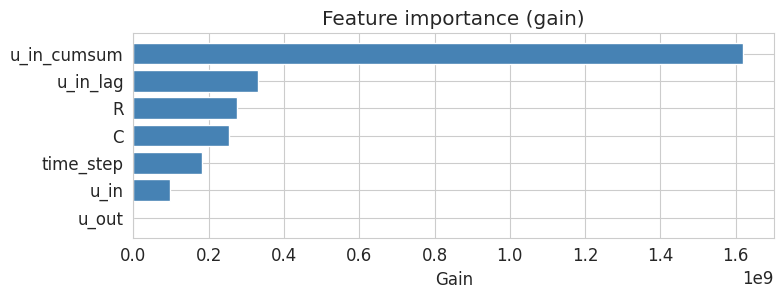

In [18]:
booster = model.booster_  # fold中の最良MAEモデル
imp_df = pd.DataFrame({
    "feature": X.columns,
    "gain": booster.feature_importance(importance_type="gain"),
    "split": booster.feature_importance(importance_type="split"),
})
imp_df["gain_pct"] = 100 * imp_df["gain"] / imp_df["gain"].sum()
imp_df = imp_df.sort_values("gain", ascending=False).reset_index(drop=True)

print("特徴量重要度（gain 降順）:")
print(imp_df.to_string(index=False))
print()
print("model.feature_importances_（LightGBM では既定で split 重要度と一致）:")
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi.to_string())

fig, ax = plt.subplots(figsize=(8, max(3.0, 0.45 * len(X.columns))))
imp_bar = imp_df.sort_values("gain")
ax.barh(imp_bar["feature"], imp_bar["gain"], color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("Feature importance (gain)")
plt.tight_layout()
plt.show()

---
## 10. 提出用ファイルの作成（ワイド予測をロングへ復元）

吸気相（`u_out=0`）はワイドモデルの fold 平均予測を `pressure_step*` として出力し、`id` 単位へ戻して提出します。
呼気相（`u_out=1`）は施策1方法Bに合わせて `pressure=0` で補完します。


In [ ]:
# 吸気相（ワイド）を fold 平均で予測
test_fold_preds = np.mean([m.predict(X_test_wide) for m in models], axis=0)
pred_cols = [col for col in y.columns]
test_pred_wide = pd.DataFrame(test_fold_preds, index=X_test_wide.index, columns=pred_cols)

# wide -> long（breath_id, step, pressure）
test_pred_long = test_pred_wide.copy()
test_pred_long["breath_id"] = test_pred_long.index
test_pred_long = test_pred_long.melt(id_vars="breath_id", var_name="target_col", value_name=TARGET)
test_pred_long["step"] = test_pred_long["target_col"].str.extract(r"step(\\d+)").astype(int)
test_pred_long = test_pred_long[["breath_id", "step", TARGET]]

# 提出 id へ戻す
test_insp_pred = test_insp_key.merge(test_pred_long, on=["breath_id", "step"], how="left")
pred_by_id = pd.Series(test_insp_pred[TARGET].to_numpy(), index=test_insp_pred["id"].to_numpy())

# 最終提出（呼気相は 0 補完）
preds = np.zeros(len(test), dtype=np.float64)
mask_insp = test["u_out"].eq(0).to_numpy()
preds[mask_insp] = test.loc[mask_insp, ID_COL].map(pred_by_id).to_numpy()
preds[~mask_insp] = 0.0

submission[TARGET] = preds
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"提出用ファイルを保存しました: {SUBMISSION_PATH}")
print("吸気行の予測数:", mask_insp.sum(), "呼気行（0補完）:", (~mask_insp).sum())
print("施策5: ワイドモデル予測をロングへ復元して提出")
submission.head(10)


提出用ファイルを保存しました: /kaggle/working//submission.csv
吸気行の予測数: 1527565 呼気行（0補完）: 2496435


,id,pressure
0,1,6.185637
1,2,5.761794
2,3,6.611669
3,4,7.652025
4,5,8.937223
5,6,9.832817
6,7,10.795554
7,8,11.693405
8,9,13.425413
9,10,14.286330
